In [1]:
import pandas as pd
df= pd.read_csv("data/processed/02_nav_history_clean.csv")
df["date"]=pd.to_datetime(df["date"])
df= df.sort_values(["amfi_code", "date"])
df["daily_return"]= df.groupby("amfi_code")["nav"].pct_change()

print(df.head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


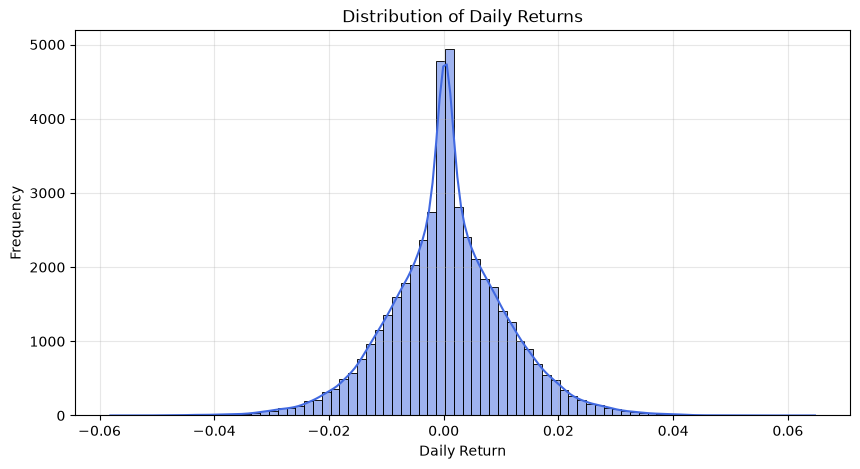

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(
    df["daily_return"].dropna(),
    bins=80,
    kde=True,
    color="royalblue"
)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()


**Insight**:

The distribution of daily returns is centered around 0%, indicating that most mutual fund schemes experience small day-to-day price changes, while extreme positive or negative returns occur infrequently.

In [3]:
import pandas as pd
import numpy as np

nav_df = pd.read_csv("data/processed/02_nav_history_clean.csv")
nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.sort_values(["amfi_code", "date"])

scheme_df = pd.read_csv("data/processed/07_scheme_performance_clean.csv")

scheme_df = scheme_df[["amfi_code", "scheme_name"]]

def calculate_cagr(group, years):

    end_date = group["date"].max()
    target_date = end_date - pd.DateOffset(years=years)

    start_rows = group[group["date"] <= target_date]

    if start_rows.empty:
        return np.nan

    start_nav = start_rows.iloc[-1]["nav"]
    end_nav = group[group["date"] == end_date].iloc[-1]["nav"]

    return round(((end_nav / start_nav) ** (1 / years) - 1) * 100, 2)
    
results = []

for fund, group in nav_df.groupby("amfi_code"):

    results.append({
        "amfi_code": fund,
        "1yr_cagr_pct": calculate_cagr(group, 1),
        "3yr_cagr_pct": calculate_cagr(group, 3),
        "5yr_cagr_pct": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(results)
cagr_df = cagr_df.merge(
    scheme_df,
    on="amfi_code",
    how="left"
)

cagr_df = cagr_df[
    [
        "amfi_code",
        "scheme_name",
        "1yr_cagr_pct",
        "3yr_cagr_pct",
        "5yr_cagr_pct"
    ]
]
cagr_df["scheme_name"] = (
    cagr_df["scheme_name"]
    .str.replace(" - Regular Plan - Growth", "", regex=False)
    .str.replace(" - Regular - Growth", "", regex=False)
)
print(cagr_df.head(10))

   amfi_code                      scheme_name  1yr_cagr_pct  3yr_cagr_pct  \
0     100016                HDFC Top 100 Fund         -2.22          1.29   
1     100025        HDFC Short Term Debt Fund          3.70          3.92   
2     100033  HDFC Mid-Cap Opportunities Fund         53.23         32.44   
3     101206       ABSL Frontline Equity Fund         47.92         28.97   
4     101207              ABSL Small Cap Fund        -23.99         -4.15   
5     101208                 ABSL Liquid Fund          7.24          6.32   
6     102885          UTI Nifty 50 Index Fund         20.21         19.67   
7     102886                 UTI Mid Cap Fund        -16.80         -0.77   
8     102887               UTI Flexi Cap Fund         13.58         25.56   
9     118632      Nippon India Large Cap Fund         33.98         22.65   

   5yr_cagr_pct  
0           NaN  
1           NaN  
2           NaN  
3           NaN  
4           NaN  
5           NaN  
6           NaN  
7       

**Insight**

The CAGR analysis reveals considerable differences in fund performance. While several schemes generated strong 1-year and 3-year annualized returns, some recorded negative CAGR, reflecting underperformance. A 5-year CAGR could not be computed because the NAV dataset does not contain five years of historical data.

In [4]:
cagr_df.to_csv("cagr_comparison.csv", index=False)

In [8]:
import pandas as pd
import numpy as np

nav_df = pd.read_csv("data/processed/02_nav_history_clean.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

annual_rf = 0.065
daily_rf = annual_rf / 252

results = []

for fund, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    mean_return = returns.mean()

    std_return = returns.std()

    if std_return == 0:
        sharpe = np.nan
    else:
        sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    results.append({
        "amfi_code": fund,
        "Sharpe Ratio": round(sharpe, 3)
    })

sharpe_df = pd.DataFrame(results)

scheme_df = pd.read_csv("data/processed/07_scheme_performance_clean.csv")

scheme_df = scheme_df[[
    "amfi_code",
    "scheme_name"
]]


sharpe_df = sharpe_df.merge(
    scheme_df,
    on="amfi_code",
    how="left"
)

sharpe_df = sharpe_df.sort_values(
    by="Sharpe Ratio",
    ascending=False
)

sharpe_df["Rank"] = range(1, len(sharpe_df) + 1)

sharpe_df = sharpe_df[[
    "Rank",
    "amfi_code",
    "scheme_name",
    "Sharpe Ratio"
]]

display(sharpe_df.head(10))

sharpe_df.to_csv(
    "sharpe_ratio_ranking.csv",
    index=False
)
print("\nSharpe Ratio ranking saved successfully!")

,Rank,amfi_code,scheme_name,Sharpe Ratio
34,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.448
30,2,120843,Kotak Flexicap Fund - Regular - Growth,1.307
36,3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.235
19,4,119551,SBI Bluechip Fund - Regular Plan - Growth,1.208
25,5,120505,ICICI Pru Midcap Fund - Regular - Growth,1.180
38,6,149323,DSP Midcap Fund - Regular - Growth,1.132
2,7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.094
9,8,118632,Nippon India Large Cap Fund - Regular - Growth,1.082
3,9,101206,ABSL Frontline Equity Fund - Regular - Growth,1.027
24,10,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.027



Sharpe Ratio ranking saved successfully!


In [10]:
import pandas as pd
import numpy as np

nav_df = pd.read_csv("data/processed/02_nav_history_clean.csv")
nav_df["date"] = pd.to_datetime(nav_df["date"])

scheme_df = pd.read_csv("data/processed/07_scheme_performance_clean.csv")

nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

rf = 0.065
daily_rf = rf / 252

results = []

for code, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    annual_return = returns.mean() * 252

    downside_returns = returns[returns < daily_rf]

    if len(downside_returns) < 2:
        downside_std = np.nan
    else:
        downside_std = downside_returns.std() * np.sqrt(252)

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (annual_return - rf) / downside_std

    results.append([code, sortino])

sortino_df = pd.DataFrame(results, columns=["amfi_code", "Sortino Ratio"])

sortino_df = sortino_df.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino_df = sortino_df.sort_values("Sortino Ratio", ascending=False)
sortino_df["Rank"] = range(1, len(sortino_df) + 1)

sortino_df = sortino_df[
    ["Rank", "amfi_code", "scheme_name", "Sortino Ratio"]
]

sortino_df["Sortino Ratio"] = sortino_df["Sortino Ratio"].round(3)

display(sortino_df.head(10))

sortino_df.to_csv("sortino_ratio_ranking.csv", index=False)

print("\nSortino Ratio ranking saved successfully!")

,Rank,amfi_code,scheme_name,Sortino Ratio
34,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.368
30,2,120843,Kotak Flexicap Fund - Regular - Growth,2.353
36,3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.135
19,4,119551,SBI Bluechip Fund - Regular Plan - Growth,2.104
25,5,120505,ICICI Pru Midcap Fund - Regular - Growth,2.010
38,6,149323,DSP Midcap Fund - Regular - Growth,1.869
9,7,118632,Nippon India Large Cap Fund - Regular - Growth,1.840
2,8,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.824
3,9,101206,ABSL Frontline Equity Fund - Regular - Growth,1.786
24,10,120504,ICICI Pru Bluechip Fund - Direct - Growth,1.785



Sortino Ratio ranking saved successfully!


In [14]:
import pandas as pd
from scipy.stats import linregress

nav_df = pd.read_csv("data/processed/02_nav_history_clean.csv")
scheme_df = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
benchmark_df = pd.read_csv("data/processed/10_benchmark_indices_clean.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

benchmark_df = benchmark_df[
    benchmark_df["index_name"].str.upper() == "NIFTY100"
]

nav_df = nav_df.sort_values(["amfi_code", "date"])
benchmark_df = benchmark_df.sort_values("date")

nav_df["fund_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

benchmark_df["benchmark_return"] = benchmark_df["close_value"].pct_change()

benchmark_df = benchmark_df[["date", "benchmark_return"]]

results = []

for code, group in nav_df.groupby("amfi_code"):

    temp = group.merge(benchmark_df, on="date", how="inner")

    temp = temp.dropna(subset=["fund_return", "benchmark_return"])

    if len(temp) < 30:
        continue

    regression = linregress(
        temp["benchmark_return"],
        temp["fund_return"]
    )

    beta = regression.slope
    alpha = regression.intercept * 252

    results.append({
        "amfi_code": code,
        "Alpha": round(alpha, 4),
        "Beta": round(beta, 4)
    })

alpha_beta_df = pd.DataFrame(results)

alpha_beta_df = alpha_beta_df.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta_df = alpha_beta_df[
    [
        "amfi_code",
        "scheme_name",
        "Alpha",
        "Beta"
    ]
]

alpha_beta_df = alpha_beta_df.sort_values(
    by="Alpha",
    ascending=False
)

display(alpha_beta_df.head(10))

alpha_beta_df.to_csv(
    "alpha_beta.csv",
    index=False
)

print("Alpha & Beta file saved successfully!")

,amfi_code,scheme_name,Alpha,Beta
21,119598,SBI Small Cap Fund - Regular Plan - Growth,0.3034,-0.0232
39,149324,DSP Small Cap Fund - Regular - Growth,0.3006,0.0115
25,120505,ICICI Pru Midcap Fund - Regular - Growth,0.2926,0.0005
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.2827,0.0181
30,120843,Kotak Flexicap Fund - Regular - Growth,0.2733,-0.0228
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.2720,0.0051
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,0.2698,0.0237
38,149323,DSP Midcap Fund - Regular - Growth,0.2660,-0.0025
16,119094,Axis Midcap Fund - Regular - Growth,0.2608,-0.0663
19,119551,SBI Bluechip Fund - Regular Plan - Growth,0.2320,-0.0318


Alpha & Beta file saved successfully!


In [15]:
import pandas as pd

nav_df = pd.read_csv("data/processed/02_nav_history_clean.csv")
scheme_df = pd.read_csv("data/processed/07_scheme_performance_clean.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.sort_values(["amfi_code", "date"])

results = []

for code, group in nav_df.groupby("amfi_code"):

    group = group.copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (group["nav"] / group["running_max"]) - 1

    min_idx = group["drawdown"].idxmin()

    max_drawdown = group.loc[min_idx, "drawdown"]

    trough_date = group.loc[min_idx, "date"]

    peak_before = group.loc[:min_idx]

    peak_idx = peak_before["nav"].idxmax()

    peak_date = group.loc[peak_idx, "date"]

    results.append({
        "amfi_code": code,
        "Maximum Drawdown (%)": round(max_drawdown * 100, 2),
        "Peak Date": peak_date.date(),
        "Trough Date": trough_date.date()
    })

drawdown_df = pd.DataFrame(results)

drawdown_df = drawdown_df.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

drawdown_df = drawdown_df[
    [
        "amfi_code",
        "scheme_name",
        "Maximum Drawdown (%)",
        "Peak Date",
        "Trough Date"
    ]
]

drawdown_df = drawdown_df.sort_values(
    by="Maximum Drawdown (%)"
)

display(drawdown_df.head(10))

drawdown_df.to_csv(
    "maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown file saved successfully!")

,amfi_code,scheme_name,Maximum Drawdown (%),Peak Date,Trough Date
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-52.57,2023-01-17,2025-10-28
17,119095,Axis Small Cap Fund - Regular - Growth,-51.68,2025-05-22,2026-05-11
4,101207,ABSL Small Cap Fund - Regular - Growth,-35.45,2024-11-21,2026-05-11
39,149324,DSP Small Cap Fund - Regular - Growth,-31.17,2024-05-03,2025-01-03
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-28.71,2024-08-28,2025-05-14
7,102886,UTI Mid Cap Fund - Regular - Growth,-28.00,2025-01-07,2026-04-27
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-24.73,2022-03-30,2022-09-15
29,120842,Kotak Emerging Equity Fund - Regular - Growth,-24.00,2023-11-09,2024-10-17
11,118634,Nippon India Small Cap Fund - Regular - Growth,-23.34,2025-04-09,2026-02-20
15,119093,Axis Bluechip Fund - Direct - Growth,-21.75,2022-02-24,2023-05-22


Maximum Drawdown file saved successfully!


In [16]:
import pandas as pd

performance = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
sharpe = pd.read_csv("sharpe_ratio_ranking.csv")
alpha = pd.read_csv("alpha_beta.csv")
drawdown = pd.read_csv("maximum_drawdown.csv")

df = performance[["amfi_code","scheme_name","return_3yr_pct","expense_ratio_pct"]]

df = df.merge(
    sharpe[["amfi_code","Sharpe Ratio"]],
    on="amfi_code",
    how="left"
)

df = df.merge(
    alpha[["amfi_code","Alpha"]],
    on="amfi_code",
    how="left"
)

df = df.merge(
    drawdown[["amfi_code","Maximum Drawdown (%)"]],
    on="amfi_code",
    how="left"
)

df["Return Rank"] = df["return_3yr_pct"].rank(ascending=False)
df["Sharpe Rank"] = df["Sharpe Ratio"].rank(ascending=False)
df["Alpha Rank"] = df["Alpha"].rank(ascending=False)
df["Expense Rank"] = df["expense_ratio_pct"].rank(ascending=True)
df["Drawdown Rank"] = df["Maximum Drawdown (%)"].rank(ascending=False)

n = len(df)

df["Return Score"] = (n - df["Return Rank"] + 1) / n * 100
df["Sharpe Score"] = (n - df["Sharpe Rank"] + 1) / n * 100
df["Alpha Score"] = (n - df["Alpha Rank"] + 1) / n * 100
df["Expense Score"] = (n - df["Expense Rank"] + 1) / n * 100
df["Drawdown Score"] = (n - df["Drawdown Rank"] + 1) / n * 100

df["Fund Score"] = (
      0.30 * df["Return Score"]
    + 0.25 * df["Sharpe Score"]
    + 0.20 * df["Alpha Score"]
    + 0.15 * df["Expense Score"]
    + 0.10 * df["Drawdown Score"]
)

df["Fund Score"] = df["Fund Score"].round(2)

df = df.sort_values("Fund Score", ascending=False)

df["Overall Rank"] = range(1, len(df)+1)

scorecard = df[
    [
        "Overall Rank",
        "amfi_code",
        "scheme_name",
        "return_3yr_pct",
        "Sharpe Ratio",
        "Alpha",
        "expense_ratio_pct",
        "Maximum Drawdown (%)",
        "Fund Score"
    ]
]

display(scorecard.head(10))

scorecard.to_csv(
    "fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

,Overall Rank,amfi_code,scheme_name,return_3yr_pct,Sharpe Ratio,Alpha,expense_ratio_pct,Maximum Drawdown (%),Fund Score
12,1,120505,ICICI Pru Midcap Fund - Regular - Growth,18.08,1.180,0.2926,1.36,-18.19,80.00
22,2,120843,Kotak Flexicap Fund - Regular - Growth,15.65,1.307,0.2733,1.45,-12.97,79.00
7,3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,16.58,1.094,0.2720,1.38,-16.22,76.25
2,4,119598,SBI Small Cap Fund - Regular Plan - Growth,23.39,0.945,0.3034,1.43,-28.71,75.62
34,5,148567,Mirae Asset Large Cap Fund - Regular - Growth,14.81,1.448,0.2698,1.46,-11.27,75.00
39,6,149324,DSP Small Cap Fund - Regular - Growth,20.08,0.950,0.3006,1.52,-31.17,69.69
38,7,149323,DSP Midcap Fund - Regular - Growth,17.16,1.132,0.2660,1.61,-17.25,68.25
11,8,120504,ICICI Pru Bluechip Fund - Direct - Growth,14.41,1.027,0.2119,0.80,-12.59,67.56
26,9,119094,Axis Midcap Fund - Regular - Growth,15.18,0.998,0.2608,1.38,-20.96,66.50
36,10,148569,Mirae Asset Tax Saver Fund - Regular - Growth,13.58,1.235,0.2827,1.60,-16.40,62.44


Fund Scorecard saved successfully!


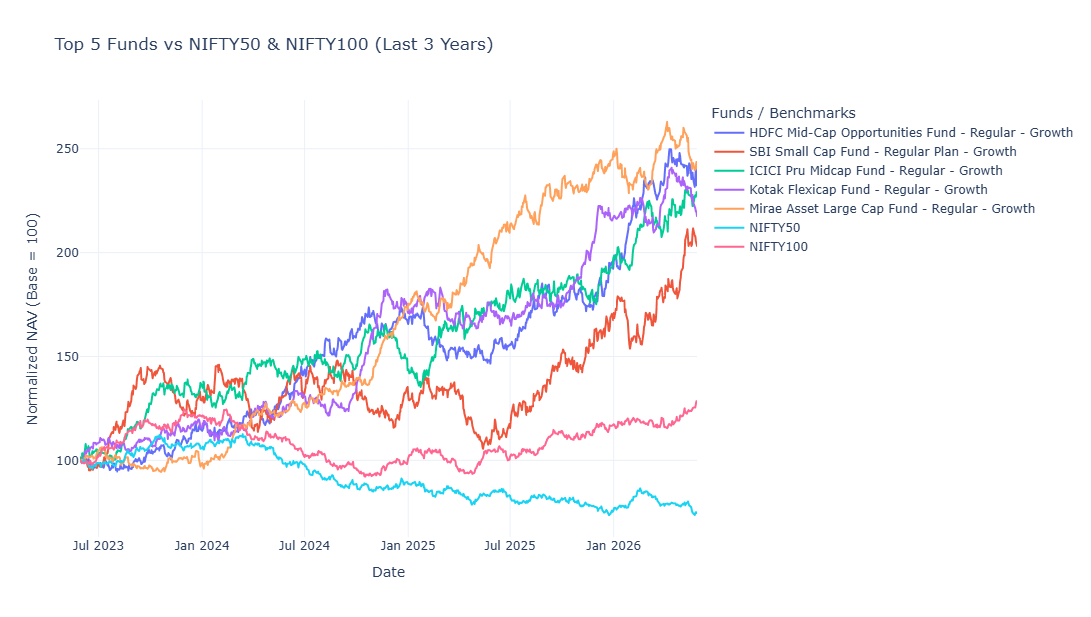

In [18]:
import pandas as pd
import plotly.express as px

nav_df = pd.read_csv("data/processed/02_nav_history_clean.csv")
scorecard = pd.read_csv("fund_scorecard.csv")
scheme_df = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
benchmark_df = pd.read_csv("data/processed/10_benchmark_indices_clean.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

top5 = scorecard.nsmallest(5, "Overall Rank")["amfi_code"]

latest_date = nav_df["date"].max()
start_date = latest_date - pd.DateOffset(years=3)

top5_nav = nav_df[
    (nav_df["amfi_code"].isin(top5)) &
    (nav_df["date"] >= start_date)
].copy()

top5_nav = top5_nav.merge(
    scheme_df[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

top5_nav["Normalized"] = top5_nav.groupby("amfi_code")["nav"].transform(
    lambda x: x / x.iloc[0] * 100
)

benchmark = benchmark_df[
    (benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])) &
    (benchmark_df["date"] >= start_date)
].copy()

benchmark["Normalized"] = benchmark.groupby("index_name")["close_value"].transform(
    lambda x: x / x.iloc[0] * 100
)

fund_plot = top5_nav.rename(
    columns={"scheme_name": "Series", "Normalized": "Value"}
)[["date", "Series", "Value"]]

benchmark_plot = benchmark.rename(
    columns={"index_name": "Series", "Normalized": "Value"}
)[["date", "Series", "Value"]]

plot_df = pd.concat([fund_plot, benchmark_plot])

fig = px.line(
    plot_df,
    x="date",
    y="Value",
    color="Series",
    title="Top 5 Funds vs NIFTY50 & NIFTY100 (Last 3 Years)",
    labels={"Value": "Normalized NAV (Base = 100)", "date": "Date"}
)

fig.update_layout(
    template="plotly_white",
    width=1100,
    height=600,
    legend_title="Funds / Benchmarks"
)

fig.show()

In [19]:
import pandas as pd
import numpy as np

nav_df = pd.read_csv("data/processed/02_nav_history_clean.csv")
scorecard = pd.read_csv("fund_scorecard.csv")
scheme_df = pd.read_csv("data/processed/07_scheme_performance_clean.csv")
benchmark_df = pd.read_csv("data/processed/10_benchmark_indices_clean.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

top5 = scorecard.nsmallest(5, "Overall Rank")["amfi_code"]

nav_df = nav_df.sort_values(["amfi_code", "date"])
nav_df["fund_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

benchmark_df = benchmark_df[
    benchmark_df["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmark_df = benchmark_df.sort_values(["index_name", "date"])
benchmark_df["benchmark_return"] = benchmark_df.groupby("index_name")["close_value"].pct_change()

tracking_results = []

for fund in top5:

    fund_name = scheme_df.loc[
        scheme_df["amfi_code"] == fund,
        "scheme_name"
    ].values[0]

    fund_returns = nav_df[
        nav_df["amfi_code"] == fund
    ][["date", "fund_return"]]

    for benchmark in ["NIFTY50", "NIFTY100"]:

        bench_returns = benchmark_df[
            benchmark_df["index_name"] == benchmark
        ][["date", "benchmark_return"]]

        merged = fund_returns.merge(
            bench_returns,
            on="date",
            how="inner"
        ).dropna()

        tracking_error = (
            (merged["fund_return"] - merged["benchmark_return"]).std()
            * np.sqrt(252)
        )

        tracking_results.append({
            "Scheme Name": fund_name,
            "Benchmark": benchmark,
            "Tracking Error": round(tracking_error, 4)
        })

tracking_df = pd.DataFrame(tracking_results)

tracking_df

,Scheme Name,Benchmark,Tracking Error
0,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,0.2331
1,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,0.2320
2,Kotak Flexicap Fund - Regular - Growth,NIFTY50,0.2051
3,Kotak Flexicap Fund - Regular - Growth,NIFTY100,0.2064
4,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,0.2298
5,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,0.2287
6,SBI Small Cap Fund - Regular Plan - Growth,NIFTY50,0.2780
7,SBI Small Cap Fund - Regular Plan - Growth,NIFTY100,0.2839
8,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,0.1940
9,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,0.1897
